<a href="https://colab.research.google.com/github/Trokzen/TelePars/blob/main/python-basics/google-colab-r.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Colab R

- Google is now supporting a Colab notebook with the R kernel
- We can run R codes directly on Colab
- R Colab Notebook Link: [R Google Colab](https://colab.fan/r)
    - Colab with R kernel
    - With base-R installed
    - Run R codes immediately
    - No need to setup
    - Save a copy in your Drive


# Лабораторная работа №2 (Вариант 20)
# Анализ среднегодовой температуры в Нью-Хейвене (nhtemp)



# Шаг 1: Установка и загрузка необходимых пакетов

In [2]:
install.packages("ggplot2")
install.packages("dplyr")
install.packages("forecast")
install.packages("tseries")
install.packages("reshape2")

library(ggplot2)
library(dplyr)
library(forecast)
library(tseries)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘quantmod’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plyr’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



# Шаг 2: Загрузка данных nhtemp

In [3]:
# Данные nhtemp уже встроены в R
data("nhtemp")
cat("=== Данные nhtemp загружены ===\n")
cat("Описание: Среднегодовая температура в Нью-Хейвене, Коннектикут\n")
cat("Период: 1912 - 1971 годы\n")
cat("Единица измерения: градусы Фаренгейта\n\n")

=== Данные nhtemp загружены ===
Описание: Среднегодовая температура в Нью-Хейвене, Коннектикут
Период: 1912 - 1971 годы
Единица измерения: градусы Фаренгейта



# Шаг 3: Предварительный просмотр данных

In [4]:
cat("=== Первые 10 значений ===\n")
print(head(nhtemp, 10))

cat("\n=== Последние 10 значений ===\n")
print(tail(nhtemp, 10))

cat("\n=== Базовая информация ===\n")
cat("Тип данных:", class(nhtemp), "\n")
cat("Длина ряда:", length(nhtemp), "лет\n")
cat("Диапазон годов:", time(nhtemp)[1], "-", tail(time(nhtemp), 1), "\n")
cat("Диапазон температур:", range(nhtemp), "°F\n")

=== Первые 10 значений ===
Time Series:
Start = 1912 
End = 1921 
Frequency = 1 
 [1] 49.9 52.3 49.4 51.1 49.4 47.9 49.8 50.9 49.3 51.9

=== Последние 10 значений ===
Time Series:
Start = 1962 
End = 1971 
Frequency = 1 
 [1] 50.5 50.9 51.7 51.4 51.7 50.8 51.9 51.8 51.9 53.0

=== Базовая информация ===
Тип данных: ts 
Длина ряда: 60 лет
Диапазон годов: 1912 - 1971 
Диапазон температур: 47.9 54.6 °F


# Шаг 4: Описательная статистика

In [5]:
cat("\n=== Описательная статистика ===\n")
summary(nhtemp)

cat("\n=== Стандартное отклонение ===\n")
cat("sd:", sd(nhtemp), "°F\n")


=== Описательная статистика ===


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  47.90   50.58   51.20   51.16   51.90   54.60 


=== Стандартное отклонение ===
sd: 1.265608 °F


# Шаг 5: Проверка пропущенных значений

In [6]:
cat("\n=== Проверка пропущенных значений ===\n")
cat("Пропусков:", sum(is.na(nhtemp)), "\n")


=== Проверка пропущенных значений ===
Пропусков: 0 


# Шаг 6: Преобразование в data.frame для удобства визуализации

In [7]:
temp_df <- data.frame(
  Year = as.numeric(time(nhtemp)),
  Temperature = as.numeric(nhtemp)
)

# Шаг 7: Визуализация временного ряда

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'


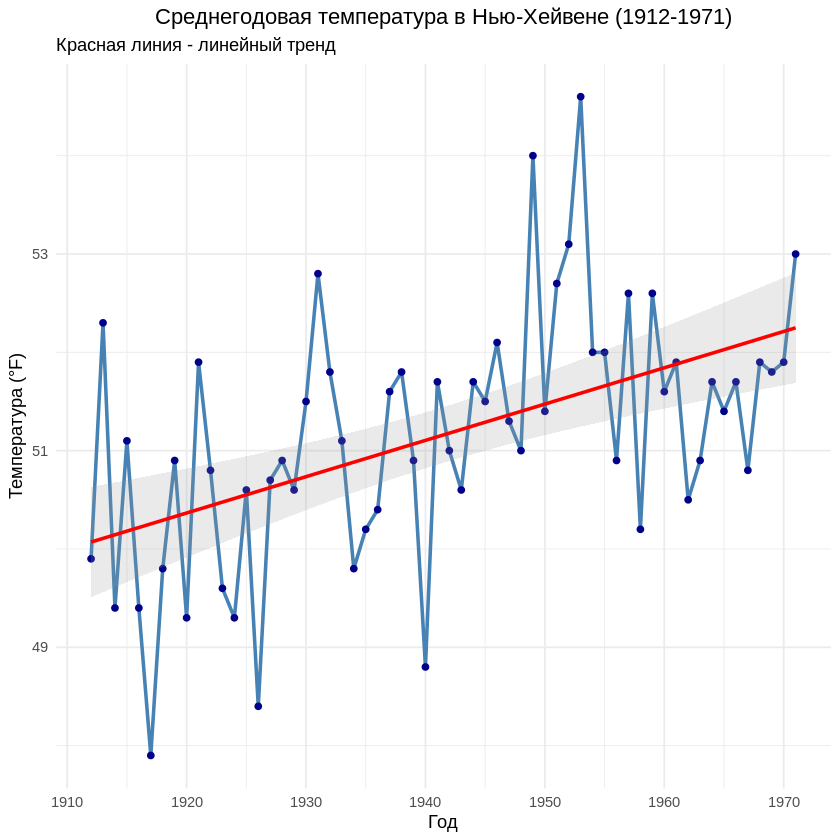

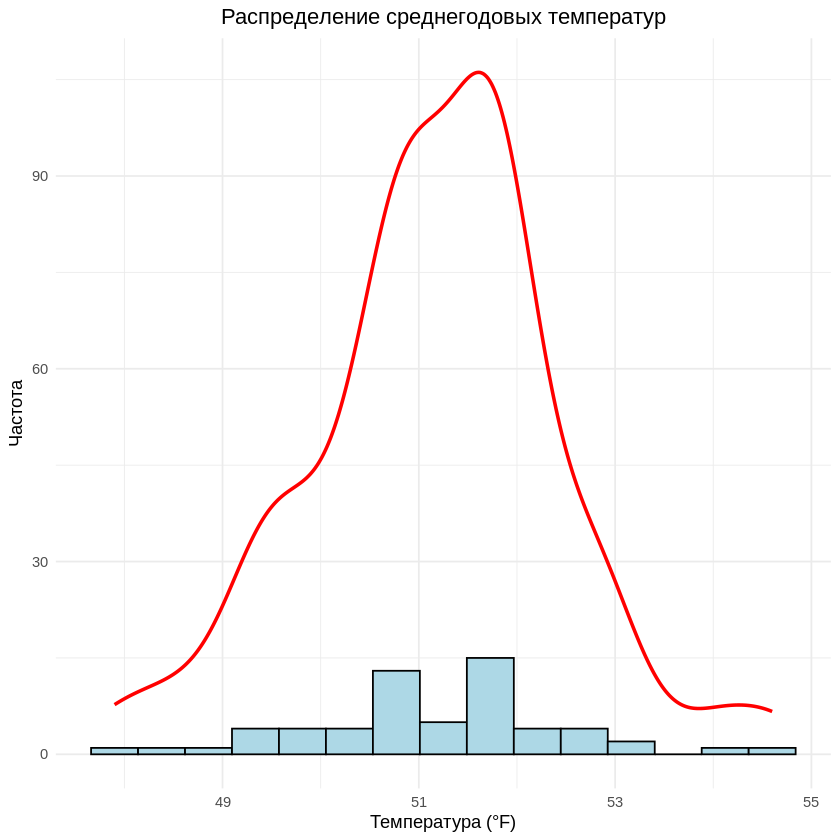

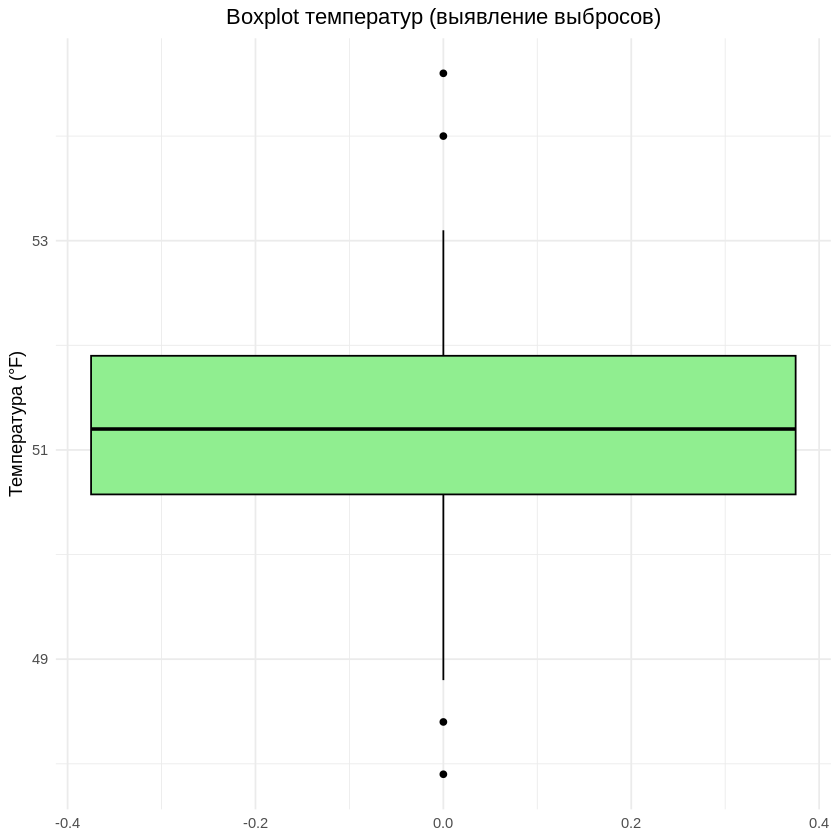

In [8]:
library(ggplot2)

# 7.1 График временного ряда с линией тренда
plot1 <- ggplot(temp_df, aes(x = Year, y = Temperature)) +
  geom_line(color = "steelblue", size = 1) +
  geom_point(color = "darkblue", size = 1.5) +
  geom_smooth(method = "lm", color = "red", se = TRUE, alpha = 0.2) +
  labs(
    title = "Среднегодовая температура в Нью-Хейвене (1912-1971)",
    subtitle = "Красная линия - линейный тренд",
    x = "Год",
    y = "Температура (°F)"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5))

print(plot1)

# 7.2 Гистограмма распределения температур
plot2 <- ggplot(temp_df, aes(x = Temperature)) +
  geom_histogram(bins = 15, fill = "lightblue", color = "black") +
  geom_density(aes(y = after_stat(count) * 5), color = "red", size = 1) +
  labs(
    title = "Распределение среднегодовых температур",
    x = "Температура (°F)",
    y = "Частота"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5))

print(plot2)

# 7.3 Boxplot (для выявления выбросов)
plot3 <- ggplot(temp_df, aes(y = Temperature)) +
  geom_boxplot(fill = "lightgreen", color = "black") +
  labs(
    title = "Boxplot температур (выявление выбросов)",
    y = "Температура (°F)"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5))

print(plot3)

# Шаг 8: Анализ тренда

In [9]:
# Линейная регрессия для определения тренда
time_index <- 1:length(nhtemp)
lm_model <- lm(as.numeric(nhtemp) ~ time_index)
summary_lm <- summary(lm_model)

cat("Коэффициенты линейного тренда:\n")
cat("  Свободный член (intercept):", round(coef(lm_model)[1], 4), "\n")
cat("  Наклон (slope):", round(coef(lm_model)[2], 6), "\n")
cat("  Наклон в пересчёте на десятилетие:", round(coef(lm_model)[2] * 10, 6), "°F/десятилетие\n")
cat("\nR-squared:", round(summary_lm$r.squared, 4), "\n")
cat("p-value:", format(summary_lm$coefficients[2, 4], scientific = FALSE, digits = 4), "\n")

if(summary_lm$coefficients[2, 4] < 0.05) {
  cat("\nВЫВОД: Тренд статистически значим (p < 0.05)\n")
} else {
  cat("\nВЫВОД: Тренд статистически не значим (p >= 0.05)\n")
}

Коэффициенты линейного тренда:
  Свободный член (intercept): 50.0339 
  Наклон (slope): 0.036921 
  Наклон в пересчёте на десятилетие: 0.369214 °F/десятилетие

R-squared: 0.2596 
p-value: 0.00003218 

ВЫВОД: Тренд статистически значим (p < 0.05)


# Шаг 9: Декомпозиция и сглаживание

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_line()`).”


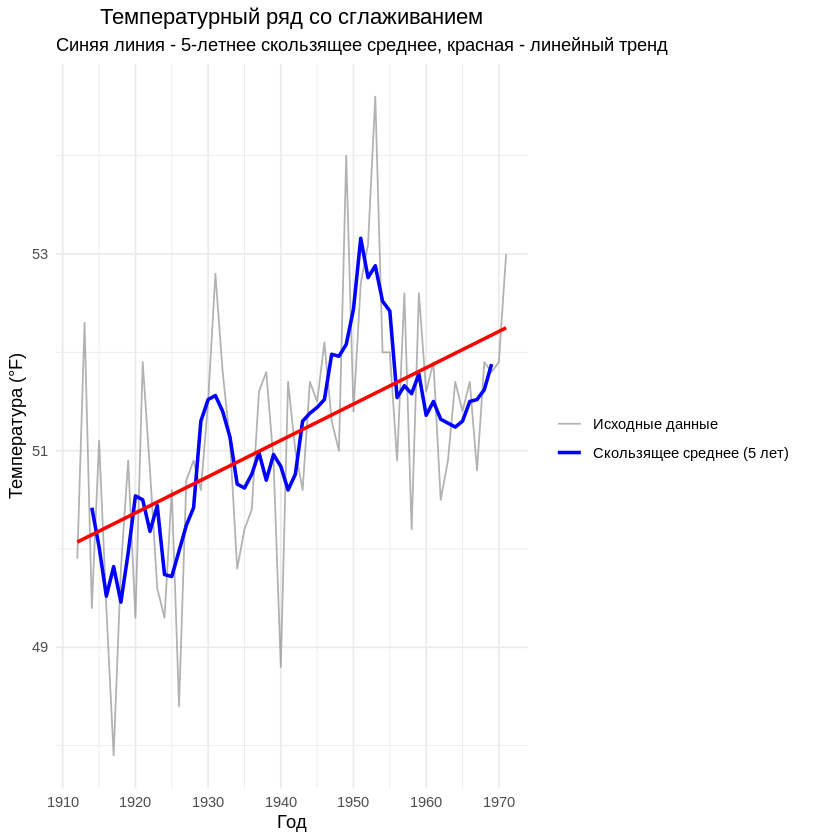

In [10]:
# Скользящее среднее
temp_df$MA5 <- stats::filter(temp_df$Temperature, rep(1/5, 5), sides = 2)

plot4 <- ggplot(temp_df, aes(x = Year)) +
  geom_line(aes(y = Temperature, color = "Исходные данные"), alpha = 0.6) +
  geom_line(aes(y = MA5, color = "Скользящее среднее (5 лет)"), size = 1) +
  geom_smooth(aes(y = Temperature), method = "lm", color = "red", se = FALSE, size = 1) +
  scale_color_manual(values = c("Исходные данные" = "gray50",
                                 "Скользящее среднее (5 лет)" = "blue")) +
  labs(
    title = "Температурный ряд со сглаживанием",
    subtitle = "Синяя линия - 5-летнее скользящее среднее, красная - линейный тренд",
    x = "Год",
    y = "Температура (°F)",
    color = ""
  ) +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5))

print(plot4)

# Шаги 10-11: Стационарность и выбросы

In [11]:
# Тест Дики-Фуллера
library(tseries)
adf_result <- adf.test(nhtemp, alternative = "stationary")
print(adf_result)

# Анализ выбросов (IQR)
detect_outliers <- function(x) {
  Q1 <- quantile(x, 0.25)
  Q3 <- quantile(x, 0.75)
  IQR_val <- Q3 - Q1
  lower <- Q1 - 1.5 * IQR_val
  upper <- Q3 + 1.5 * IQR_val
  return(x < lower | x > upper)
}

outliers <- detect_outliers(nhtemp)
cat("Количество выбросов:", sum(outliers), "\n")


	Augmented Dickey-Fuller Test

data:  nhtemp
Dickey-Fuller = -3.2773, Lag order = 3, p-value = 0.08376
alternative hypothesis: stationary

Количество выбросов: 4 


# Шаги 12-14: Группировка по десятилетиям и Итоги

In [12]:
# Десятилетия
library(dplyr)
temp_df$Decade <- floor(temp_df$Year / 10) * 10
decade_stats <- temp_df %>%
  group_by(Decade) %>%
  summarize(Mean_Temp = mean(Temperature, na.rm = TRUE), .groups = "drop")

print(decade_stats)

# Итоговый вывод
cat("\nЗАКЛЮЧЕНИЕ: ")
if(summary_lm$coefficients[2, 4] < 0.05) {
  cat("Обнаружен статистически значимый тренд потепления.\n")
} else {
  cat("Значимого тренда не обнаружено.\n")
}

# A tibble: 7 × 2
  Decade Mean_Temp
   <dbl>     <dbl>
1   1910      50.1
2   1920      50.2
3   1930      51.2
4   1940      51.4
5   1950      52.2
6   1960      51.4
7   1970      52.4

ЗАКЛЮЧЕНИЕ: Обнаружен статистически значимый тренд потепления.
